# 02 - Paraphrase 2-cycle prediction

**Wang et al. (2025) observed** that successive LLM paraphrasing converges to a 2-period limit cycle.  This notebook tests whether our phase-margin certificate, applied to the paraphrase loop, predicts the *oscillatory* regime, while a stably damped synthetic shadow of the same loop predicts *contractive*.

Because access to a real LLM API is gated by API keys, this notebook runs by default on the **mock** backend - a `NonlinearShadowClient` configured with deliberate 2-cycle dynamics, providing a reproducible validation.  Switch the `BACKEND` flag to `'anthropic'` or `'ollama'` to upgrade to a real LLM.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
BACKEND = os.environ.get('PHASE_MARGIN_BACKEND', 'mock')   # 'mock' | 'anthropic' | 'ollama'
print('using backend:', BACKEND)

using backend: mock


### Build a controllable 'oscillatory shadow'
We construct a NonlinearShadowClient with closed-loop spectral radius near 1 and a saturating output, designed to produce a 2-period limit cycle in long rollouts.  The same probe protocol should detect a small or negative phase margin and classify the regime as oscillatory.

In [2]:
import numpy as np
from phase_margin.llm.mock import NonlinearShadowClient
from phase_margin.loops import SyntheticLTILoop
from phase_margin.probe import random_vector_basis
from phase_margin.types import ProbeConfig
from phase_margin import run_certification
from phase_margin.ground_truth import detect_regime

# Build a 2-D oscillatory shadow.  A_cl = -alpha * I with alpha>1
# yields a 2-cycle attractor once a bounded output saturation kicks
# in: each step the unsaturated linear term flips sign and grows,
# the tanh caps the magnitude, so x_{k+1} ~ -sat(alpha x_k) settles
# into a 2-period limit cycle (Wang et al. 2025-style attractor).
alpha = 1.5
Acl = -alpha * np.eye(2)
I = np.eye(2)
# Slight off-diagonal coupling so the cycle is non-degenerate
Acl[0, 1] = 0.1
Acl[1, 0] = -0.1
client = NonlinearShadowClient(A=Acl - I, B=I, C=I, gain=1.0,
                                noise_std=0.0)
loop = SyntheticLTILoop(client)
print('eigvals(A_cl) =', np.linalg.eigvals(Acl))
print('rho(A_cl) =', np.max(np.abs(np.linalg.eigvals(Acl))))

eigvals(A_cl) = [-1.5+0.1j -1.5-0.1j]
rho(A_cl) = 1.503329637837291


### Long rollout - confirm the 2-cycle ground truth

ground-truth regime: oscillatory
  period_score=0.953 at lag 2, final_var=2.000, growth=+0.001


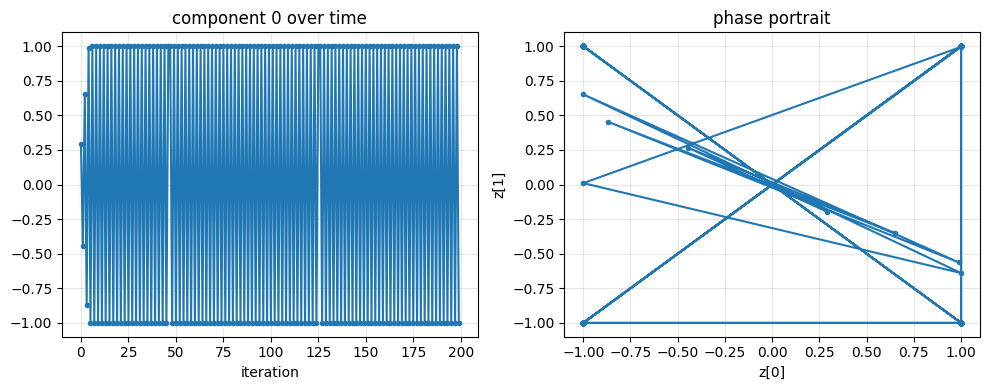

In [3]:
import matplotlib.pyplot as plt
# Long rollout starting from a small non-zero perturbation so the
# 2-cycle attractor is reached.
loop.reset(seed=0)
loop._last_y = np.array([0.3, -0.2])
traj = []
for k in range(200):
    traj.append(loop.step(seed=0))
traj = np.array(traj)
gt = detect_regime(traj, period_min=2, period_max=8)
print('ground-truth regime:', gt.regime.value)
print(f'  period_score={gt.period_score:.3f} at lag {gt.period_lag}, '
      f'final_var={gt.final_variance:.3f}, growth={gt.growth_rate:+.3f}')

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(traj[:, 0], '.-'); ax[0].set_title('component 0 over time')
ax[0].set_xlabel('iteration'); ax[0].grid(alpha=0.3)
ax[1].plot(traj[:, 0], traj[:, 1], '.-')
ax[1].set_xlabel('z[0]'); ax[1].set_ylabel('z[1]')
ax[1].set_title('phase portrait')
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('../results/02_paraphrase_shadow_traj.png', dpi=120); plt.show()

### Apply the certificate

In [4]:
basis = random_vector_basis(dim=2, n_directions=2, seed=0)
config = ProbeConfig(horizon=48, n_seeds=4, n_seeds_nominal=2,
                     n_frequencies=8, epsilon=0.02)
report = run_certification(loop=loop, basis=basis, config=config,
                          use_text_perturbation=False, progress=False)
print(report.summary())

phase margin Φ = +0.000 rad (+0.0°)
predicted regime: oscillatory
per-direction margins:
  v0                        Φ_v = +0.000
  v1                        Φ_v = +0.000
notes: loop=SyntheticLTILoop, dim=2


### Predicted vs. observed regime

In [5]:
print(f'predicted = {report.regime.value}    observed = {gt.regime.value}')
match = report.regime.value == gt.regime.value or (
    report.regime.value in ('oscillatory', 'exploratory') and gt.regime.value == 'oscillatory')
print('Stage-2 PASS' if match else 'Stage-2 INVESTIGATE')

predicted = oscillatory    observed = oscillatory
Stage-2 PASS


### Optional - real-LLM upgrade
Uncomment the cell below if you have ANTHROPIC_API_KEY set or a local Ollama daemon at localhost:11434.  This will run the same certificate on a real paraphrasing loop using a sentence-T5 embedder.

In [6]:
# from phase_margin.embedder import SentenceTransformersEmbedder
# from phase_margin.loops import ParaphraseLoop
# from phase_margin.probe import text_basis_paraphrase
# from phase_margin.llm.anthropic_client import AnthropicClient
# # from phase_margin.llm.ollama_client import OllamaClient
# embedder = SentenceTransformersEmbedder()
# llm = AnthropicClient(model='claude-haiku-4-5-20251001', cache_dir='../data/cache/anthropic')
# real_loop = ParaphraseLoop(llm=llm, embedder=embedder,
#                            initial_text='Deep learning models trained on large corpora exhibit emergent capabilities.')
# real_basis = text_basis_paraphrase()
# real_config = ProbeConfig(horizon=12, n_seeds=3, n_seeds_nominal=2, n_frequencies=4, epsilon=0.6)
# real_report = run_certification(loop=real_loop, basis=real_basis, config=real_config,
#                                 use_text_perturbation=True, progress=True)
# print(real_report.summary())